In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold, chi2, mutual_info_classif, f_classif
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

## Đọc dữ liệu

In [18]:
file_path = "data/csv/cicddos_2019.csv"  # Thay bằng đường dẫn file của bạn
df = pd.read_csv(file_path)


In [34]:
df1 = df.drop(columns=['Label'])
df2 = df['Label']

# Thay thế NaN bằng trung vị (median)
df1.fillna(df1.median(), inplace=True)

# Thay thế Infinity bằng giá trị lớn nhất trong cột đó
df1.replace([np.inf, -np.inf], np.nan, inplace=True)
df1.fillna(df1.median(), inplace=True)

group = pd.concat([df1, df2], axis=1)



## Kiểm tra dữ liệu

🔍 Các đặc trưng có tương quan cao giữa NetBIOS & Portmap:
Series([], dtype: float64)


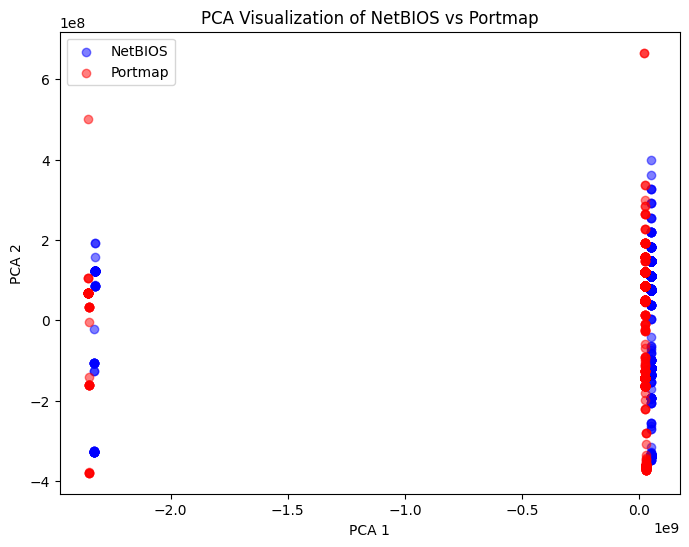

In [41]:
# 2️⃣ Lọc dữ liệu theo nhãn NetBIOS & Portmap
df_netbios = group[group['Label'] == 'NetBIOS'].drop(columns=['Label'])
df_portmap = group[group['Label'] == 'Portmap'].drop(columns=['Label'])

# 3️⃣ Kiểm tra tương quan giữa hai nhãn
corr_matrix = df_netbios.corrwith(df_portmap, axis=0)
high_corr_features = corr_matrix[abs(corr_matrix) < 0.9]  # Lọc các đặc trưng có tương quan cao

print("🔍 Các đặc trưng có tương quan cao giữa NetBIOS & Portmap:")
print(high_corr_features)

# 4️⃣ Dùng PCA để trực quan hóa dữ liệu (chuyển xuống 2D)
pca = PCA(n_components=2)
pca_netbios = pca.fit_transform(df_netbios)
pca_portmap = pca.fit_transform(df_portmap)

plt.figure(figsize=(8, 6))
plt.scatter(pca_netbios[:, 0], pca_netbios[:, 1], alpha=0.5, label="NetBIOS", color="blue")
plt.scatter(pca_portmap[:, 0], pca_portmap[:, 1], alpha=0.5, label="Portmap", color="red")
plt.legend()
plt.title("PCA Visualization of NetBIOS vs Portmap")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

# 5️⃣ Vẽ Boxplot để kiểm tra sự phân bố của một số đặc trưng quan trọng
features_to_check = high_corr_features.index[:5]  # Chọn 5 đặc trưng đầu tiên có tương quan cao

for feature in features_to_check:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=group['Label'], y=group[feature], data=group[group['Label'].isin(['NetBIOS', 'Portmap'])])
    plt.title(f"Boxplot của {feature}")
    plt.show()

## Sử dụng HEAT map

In [ ]:
# Giả sử bạn có một DataFrame với 78 đặc trưng
dff = pd.read_csv("data/CICDDOS2019/csv/_merged_output.csv")
df  = dff.drop(columns=["Label"])

# Tính toán ma trận tương quan
corr_matrix = df.corr()

# Vẽ heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt=".2f", linewidths=0.5)
plt.title("Heatmap của Ma trận Tương quan")
plt.show()

In [16]:
# Xác định các cặp tương quan cao
threshold = 0.9
upper_triangle = np.triu(np.ones(corr_matrix.shape), k=1)
high_corr_pairs = (corr_matrix.abs() > threshold) & (upper_triangle == 1)

# Danh sách các cột cần loại bỏ
to_drop = set()
for col in high_corr_pairs.columns:
    if any(high_corr_pairs[col]):
        to_drop.add(col)

# Loại bỏ các cột tương quan cao
df_reduced = df.drop(columns=to_drop)

print(f"Số đặc trưng còn lại sau khi loại bỏ: {df_reduced.shape[1]}")
print("Các đặc trưng còn lại sau khi loại bỏ:")
print(df_reduced.columns.tolist())


Số đặc trưng còn lại sau khi loại bỏ: 49
Các đặc trưng còn lại sau khi loại bỏ:
['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Max', 'Flow IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Bwd Packets/s', 'Packet Length Max', 'FIN Flag Count', 'SYN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ratio', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'Init Fwd Win Bytes', 'Init Bwd Win Bytes', 'Fwd Seg Size Min', 'Active Mean', 'Active Std', 'Active Max', '

## Chi-Square, Mutual Information, ANOVA (F-test)

In [5]:


# 1️⃣ Đọc dữ liệu
df = pd.read_csv("data/csv/cicddos_2019.csv")

# Loại bỏ các cột không chứa thông tin hữu ích
# df = df.drop(columns=["Device_Name", "Attack", "Attack_subType"], errors="ignore")
df = df.drop(columns=["Protocol", "Flow Packets/s", "Flow Bytes/s"], errors="ignore")

# Chuẩn bị dữ liệu
X = df.drop(columns=["Label"])
y = df["Label"]

# 2️⃣ Loại bỏ đặc trưng có phương sai thấp
var_thresh = VarianceThreshold(threshold=0.01)
X_var = var_thresh.fit_transform(X)
selected_var_features = X.columns[var_thresh.get_support()]

# 3️⃣ Loại bỏ đặc trưng có tương quan cao với nhau
corr_matrix = X[selected_var_features].corr(method="spearman")  # Hoặc method="pearson" khi dữ liệu tuyến tính (tắng liên tục hoặc giảm liên tục)
high_corr_features = set()
corr_threshold = 0.9  # Ngưỡng loại bỏ tương quan cao

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > corr_threshold:
            high_corr_features.add(corr_matrix.columns[i])

selected_corr_features = [f for f in selected_var_features if f not in high_corr_features]

# 4️⃣ Tính điểm Chi-Square, Mutual Information và ANOVA (F-test)
X_scaled = MinMaxScaler().fit_transform(X[selected_corr_features])  # Chuẩn hóa dữ liệu

chi_scores, _ = chi2(X_scaled, y)
mi_scores = mutual_info_classif(X_scaled, y)
anova_scores, _ = f_classif(X_scaled, y)


# sau khi có điểm Chi-Square, Mutual Information, ANOVA (F-test), chuẩn hóa, tính tổng trung bình, sắp xếp theo độ quan trọng và lấy các đặc trưng lớn hơn ngưỡng
# 5️⃣ Tạo DataFrame chứa điểm số
feature_scores = pd.DataFrame({
    "Feature": selected_corr_features,
    "Chi-Square": chi_scores,
    "Mutual Information": mi_scores,
    "ANOVA (F-test)": anova_scores
})

# 6️⃣ Chuẩn hóa điểm số để so sánh dễ dàng
for col in ["Chi-Square", "Mutual Information", "ANOVA (F-test)"]:
    feature_scores[col] = feature_scores[col] / feature_scores[col].sum()

# 7️⃣ Tính điểm tổng hợp bằng trung bình cộng
feature_scores["Total Score"] = feature_scores[["Chi-Square", "Mutual Information", "ANOVA (F-test)"]].mean(axis=1)

# Sắp xếp theo độ quan trọng
feature_scores = feature_scores.sort_values(by="Total Score", ascending=False)

# 8️⃣ Lọc đặc trưng tốt nhất: chỉ giữ lại những đặc trưng có điểm > 1% tổng trọng số
threshold = 0.01
selected_features = feature_scores[feature_scores["Total Score"] > threshold]["Feature"].tolist()

# In ra danh sách đặc trưng còn lại
print(f"Số đặc trưng tốt nhất sau khi áp dụng tất cả phương pháp: {len(selected_features)}")
print("Danh sách đặc trưng được chọn:", selected_features)


Số đặc trưng tốt nhất sau khi áp dụng tất cả phương pháp: 22
Danh sách đặc trưng được chọn: ['ACK Flag Count', 'URG Flag Count', 'Fwd Packets Length Total', 'Init Fwd Win Bytes', 'Fwd Packets/s', 'CWE Flag Count', 'Fwd PSH Flags', 'Flow Duration', 'Down/Up Ratio', 'Packet Length Std', 'Fwd IAT Total', 'Flow IAT Std', 'Fwd Header Length', 'Fwd Act Data Packets', 'Bwd Packet Length Min', 'Bwd Packet Length Std', 'Fwd Seg Size Min', 'Init Bwd Win Bytes', 'Fwd Packet Length Std', 'Total Fwd Packets', 'Total Backward Packets', 'Bwd Packets Length Total']
